In [25]:
import pandas as pd
df=pd.read_csv("manufacturing_defect_dataset.csv")
df.head()

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost 

###check for missing values


In [27]:
df.isnull().sum()

,0
ProductionVolume,0
ProductionCost,0
SupplierQuality,0
DeliveryDelay,0
DefectRate,0
QualityScore,0
MaintenanceHours,0
DowntimePercentage,0
InventoryTurnover,0
StockoutRate,0


###check for duplicate rows

In [28]:
df.duplicated().sum()

np.int64(0)

### Outlier Detection using Interquartile Range (IQR)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude the target variable and any non-numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'DefectStatus' in numeric_cols:
    numeric_cols.remove('DefectStatus')
# If 'outlier' column exists from a previous run, exclude it from IQR analysis
if 'outlier' in numeric_cols:
    numeric_cols.remove('outlier')

# Create a dictionary to store outliers for each column
outliers_iqr = {}

print("Checking for outliers using IQR method:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not col_outliers.empty:
        outliers_iqr[col] = col_outliers
        print(f"  Column '{col}': {len(col_outliers)} outliers detected.")

# Total number of unique rows identified as outliers across all columns
all_outlier_indices = set()
for col, col_outlier_df in outliers_iqr.items():
    all_outlier_indices.update(col_outlier_df.index)

print(f"\nTotal unique rows identified as outliers across all relevant numerical columns by IQR: {len(all_outlier_indices)}")

Checking for outliers using IQR method:

Total unique rows identified as outliers across all relevant numerical columns by IQR: 0


###EDA

Histograms

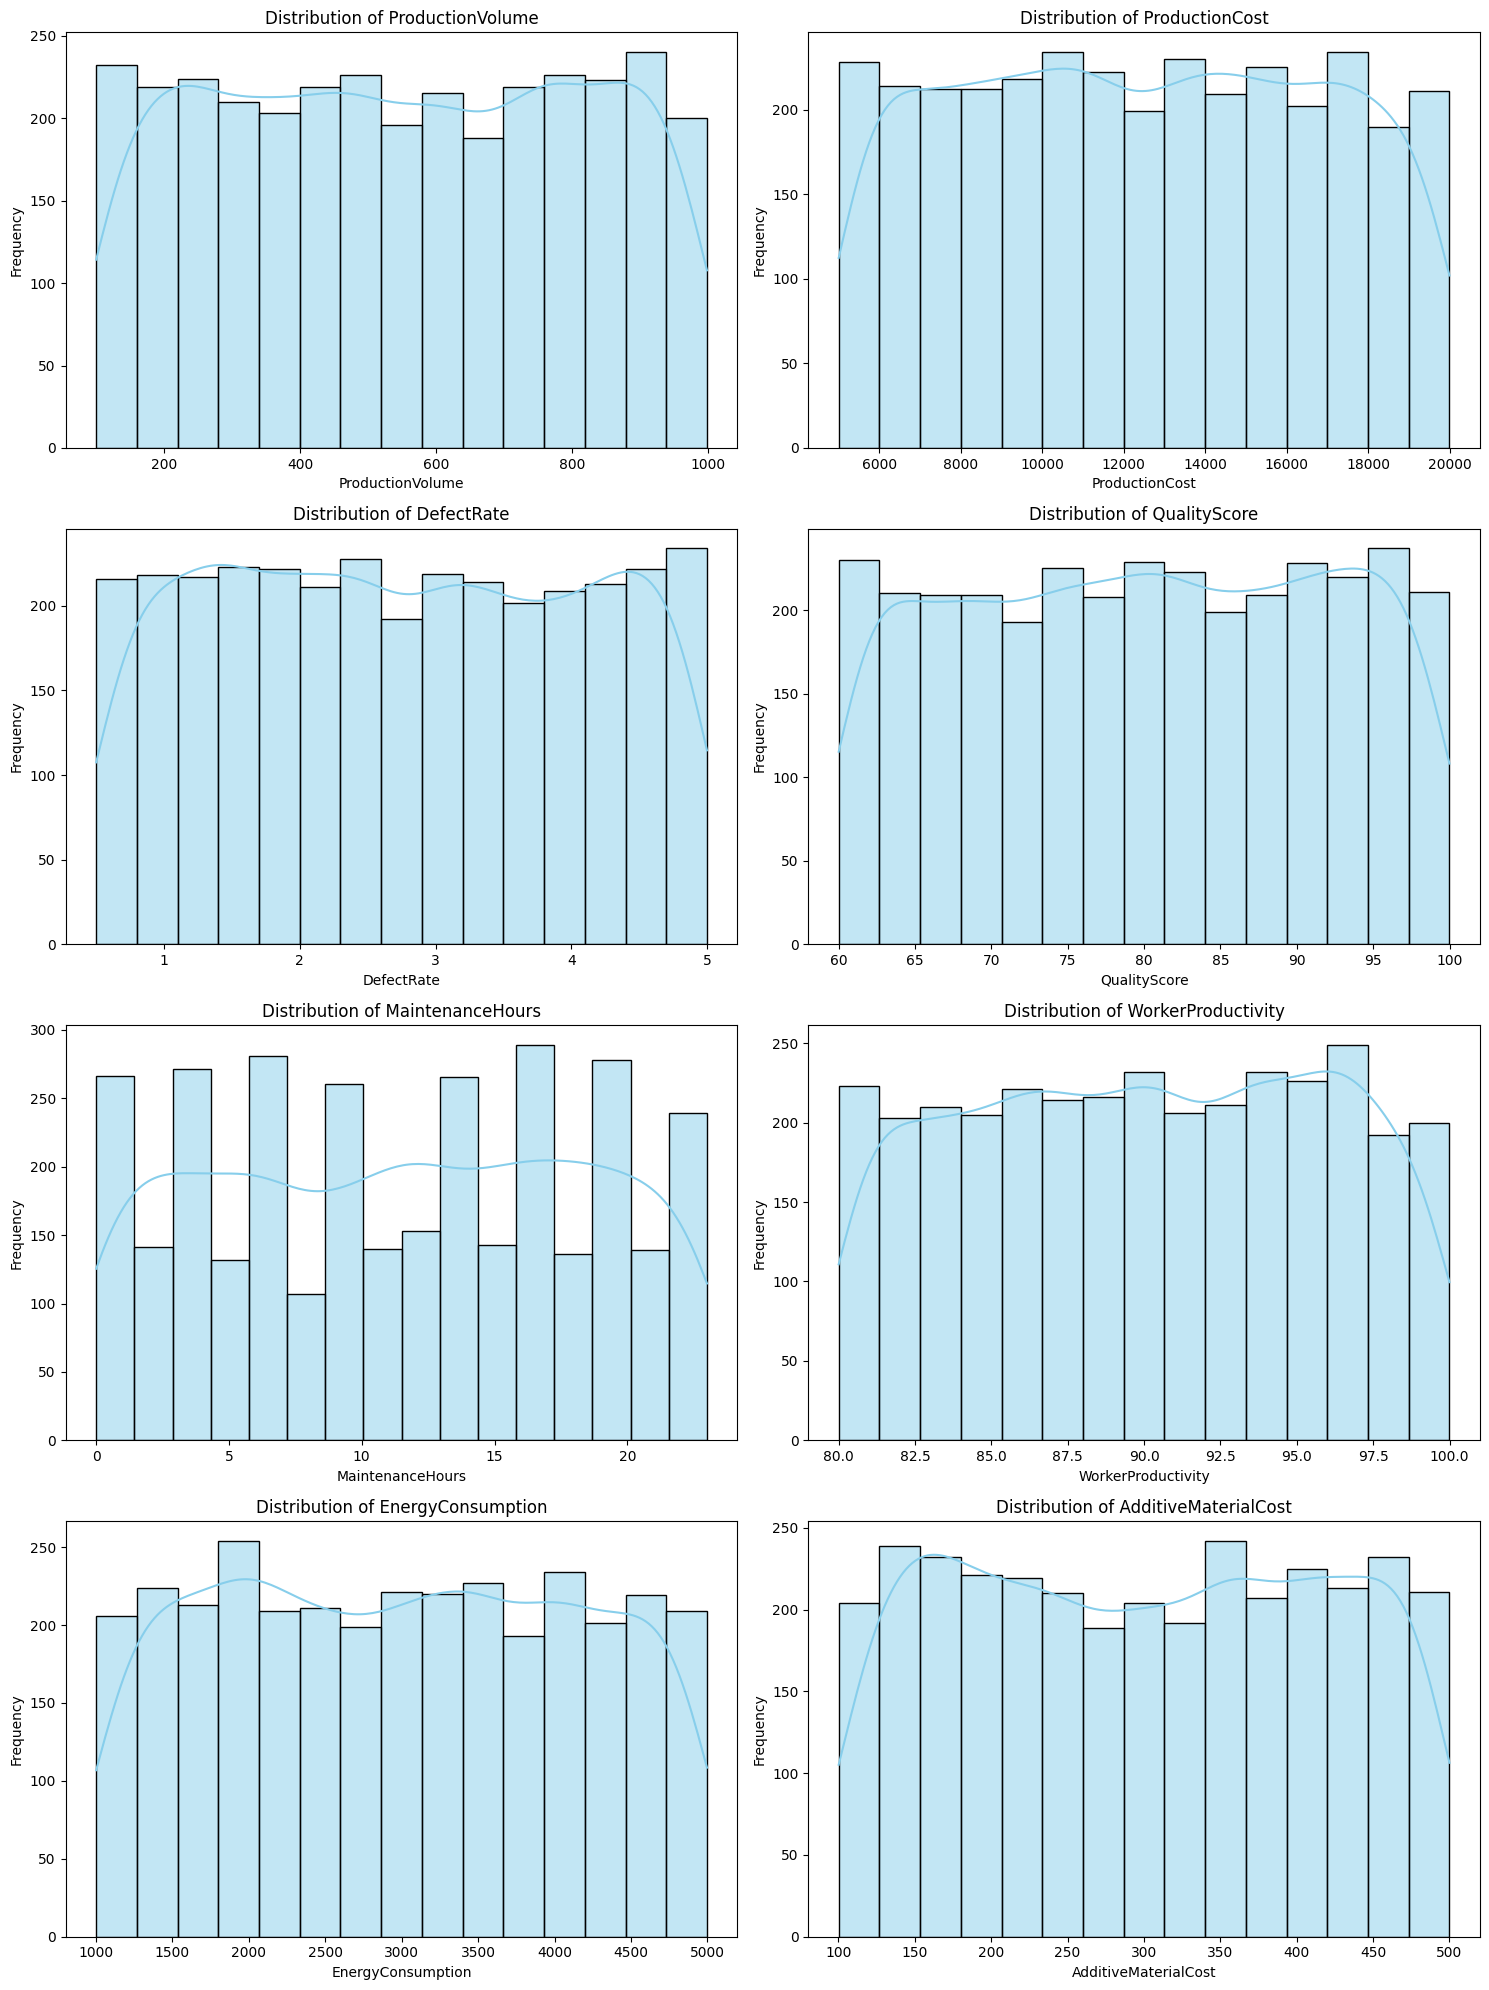

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

key_features = [
    'ProductionVolume',
    'ProductionCost',
    'DefectRate',
    'QualityScore',
    'MaintenanceHours',
    'WorkerProductivity',
    'EnergyConsumption',
    'AdditiveMaterialCost'
]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


Correlation Heatmap

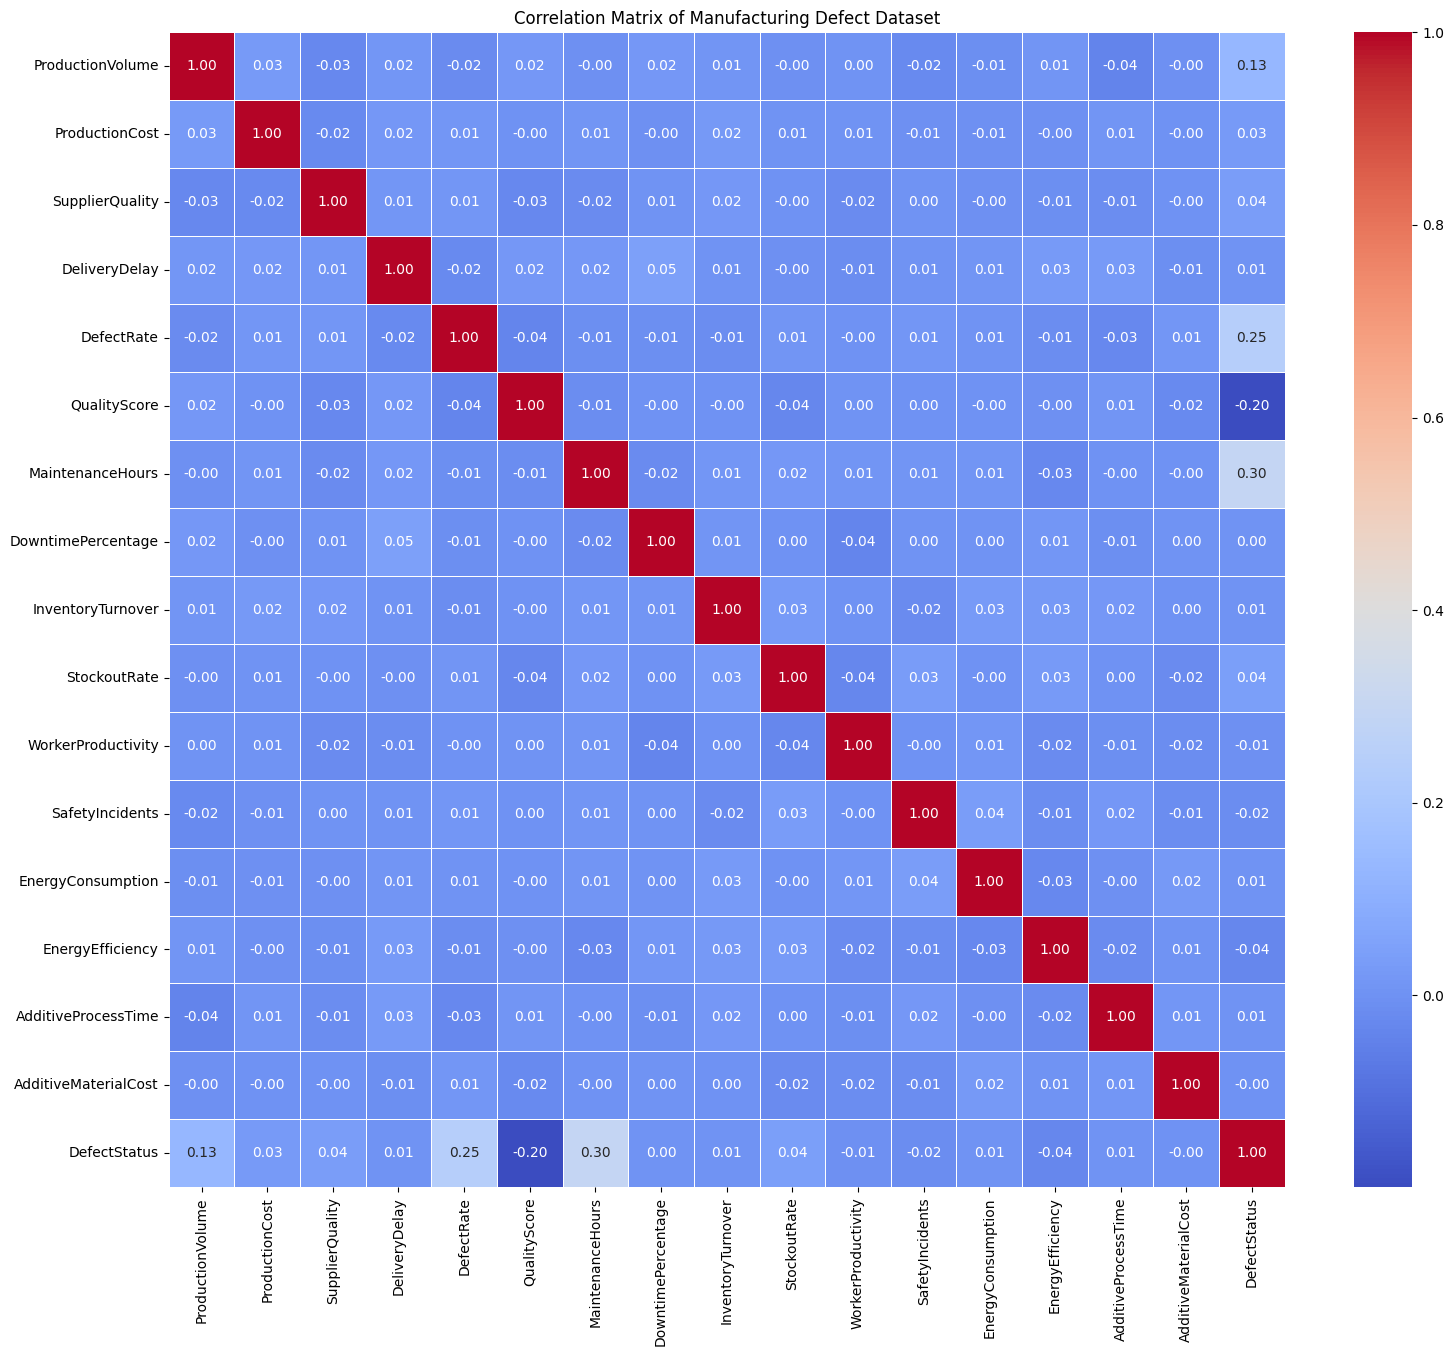

In [31]:

correlation_matrix = df.corr()
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Manufacturing Defect Dataset')
plt.show()

### Checking for Multicollinearity using Variance Inflation Factor (VIF)

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Exclude the target variable from the feature set
X = df.drop('DefectStatus', axis=1)

# Add a constant to the DataFrame to calculate VIF for all features including the intercept
X_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data['feature'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
display(vif_data.sort_values(by='VIF', ascending=False))

,feature,VIF
0,const,627.523015
4,DeliveryDelay,1.006107
10,StockoutRate,1.005745
1,ProductionVolume,1.005544
15,AdditiveProcessTime,1.005408
14,EnergyEfficiency,1.005234
8,DowntimePercentage,1.004823
6,QualityScore,1.004711
5,DefectRate,1.004244
9,InventoryTurnover,1.004239


### Separate features and target variable

In [33]:
X = df.drop('DefectStatus', axis=1)
y = df['DefectStatus']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

display(X.head())
display(y.head())

Shape of features (X): (3240, 16)
Shape of target (y): (3240,)


,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964


,DefectStatus
0,1
1,1
2,1
3,1
4,1


### Split the dataset into training and testing sets

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2592, 16)
Shape of X_test: (648, 16)
Shape of y_train: (2592,)
Shape of y_test: (648,)


### Feature Scaling using StandardScaler

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of scaled X_train: {X_train_scaled.shape}")
print(f"Shape of scaled X_test: {X_test_scaled.shape}")

display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Shape of scaled X_train: (2592, 16)
Shape of scaled X_test: (648, 16)


,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost
0,1.106642,0.112341,-0.913676,-0.902245,-0.654558,0.751284,1.098294,-0.725719,1.541736,-1.552666,1.472542,0.829450,0.655936,-1.177739,0.575427,0.180752
1,1.482985,0.482229,1.659022,1.437544,-0.450982,-1.209465,-1.229763,1.567679,1.220257,0.299764,-0.298372,0.829450,0.331537,1.093233,-0.182706,0.149475
2,1.218009,-1.649425,1.333366,1.437544,-0.249936,0.954066,0.952790,0.882857,-1.084855,-0.196390,-0.130635,0.139927,1.119358,0.103857,-1.486741,0.737124
3,1.651956,1.673902,-0.456834,-0.902245,-1.237500,-0.053691,1.098294,-0.775520,-1.037701,-1.116099,-1.146213,0.829450,-0.482615,-1.166722,0.238597,0.354287
4,1.025997,0.267326,-1.461907,1.437544,-0.064221,1.513458,0.661783,-0.518228,-0.931866,-0.047061,-0.121672,0.829450,0.590589,1.557404,-1.080733,-0.523230


### Check Class Distribution of Target Variable

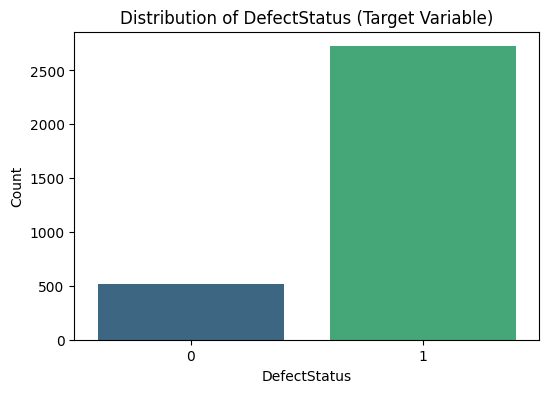

Class distribution:


,count
DefectStatus,
1,2723
0,517


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Distribution of DefectStatus (Target Variable)')
plt.xlabel('DefectStatus')
plt.ylabel('Count')
plt.show()

print("Class distribution:")
display(y.value_counts())

### Handle Class Imbalance using SMOTE

In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Shape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)

print("\nNew class distribution after SMOTE:")
display(pd.Series(y_train_resampled).value_counts())

Shape of X_train_resampled: (4354, 16)
Shape of y_train_resampled: (4354,)

New class distribution after SMOTE:


,count
DefectStatus,
1,2177
0,2177


### Train a Logistic Regression Model

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets and handles L1/L2 regularization

# Train the model using the SMOTE-resampled training data
log_reg_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled test data
y_pred = log_reg_model.predict(X_test_scaled)

print("Logistic Regression Model Training Complete.")

Logistic Regression Model Training Complete.


### Evaluate the Logistic Regression Model

Model Evaluation:
Accuracy: 0.7685
Precision: 0.9439
Recall: 0.7711
F1-Score: 0.8488

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.75      0.51       102
           1       0.94      0.77      0.85       546

    accuracy                           0.77       648
   macro avg       0.66      0.76      0.68       648
weighted avg       0.86      0.77      0.79       648


Confusion Matrix:


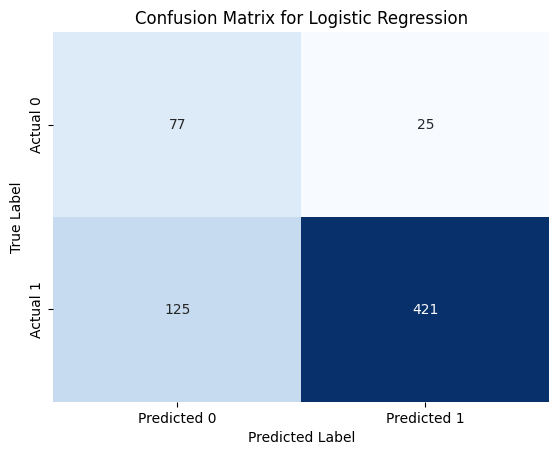

In [39]:
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### Train and Evaluate a Random Forest Model

In [40]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)

# Train the model using the SMOTE-resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled test data
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Model Training Complete.")

Random Forest Model Training Complete.


Random Forest Model Evaluation:
Accuracy: 0.9552
Precision: 0.9591
Recall: 0.9890
F1-Score: 0.9739

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       102
           1       0.96      0.99      0.97       546

    accuracy                           0.96       648
   macro avg       0.94      0.88      0.91       648
weighted avg       0.95      0.96      0.95       648


Confusion Matrix (Random Forest):


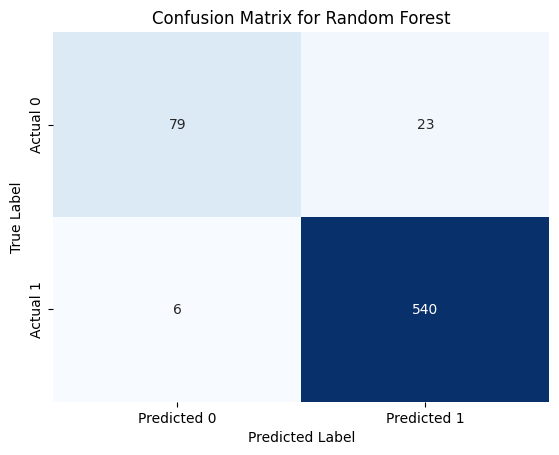

In [41]:
print("Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix (Random Forest):")
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest')
plt.show()

### Train and Evaluate a Decision Tree Model

In [42]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model using the SMOTE-resampled training data
dt_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled test data
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree Model Training Complete.")

Decision Tree Model Training Complete.


Decision Tree Model Evaluation:
Accuracy: 0.8858
Precision: 0.9556
Recall: 0.9066
F1-Score: 0.9305

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.61      0.77      0.68       102
           1       0.96      0.91      0.93       546

    accuracy                           0.89       648
   macro avg       0.78      0.84      0.81       648
weighted avg       0.90      0.89      0.89       648


Confusion Matrix (Decision Tree):


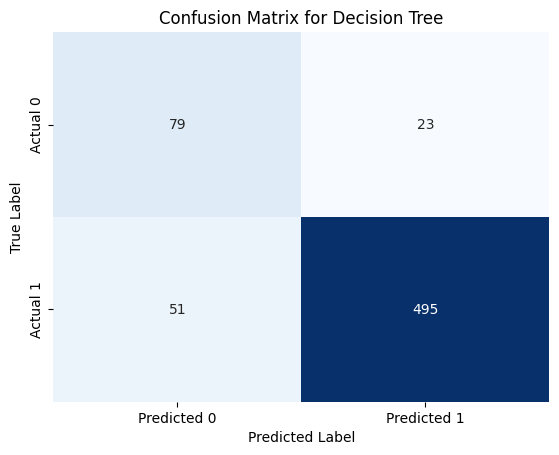

In [43]:
print("Decision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")

print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix (Decision Tree):")
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

### Train and Evaluate an XGBoost Model

In [44]:
import xgboost as xgb

# Initialize the XGBoost Classifier model
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Train the model using the SMOTE-resampled training data
xgb_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Model Training Complete.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:14:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Model Training Complete.


XGBoost Model Evaluation:
Accuracy: 0.9552
Precision: 0.9591
Recall: 0.9890
F1-Score: 0.9739

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       102
           1       0.96      0.99      0.97       546

    accuracy                           0.96       648
   macro avg       0.94      0.88      0.91       648
weighted avg       0.95      0.96      0.95       648


Confusion Matrix (XGBoost):


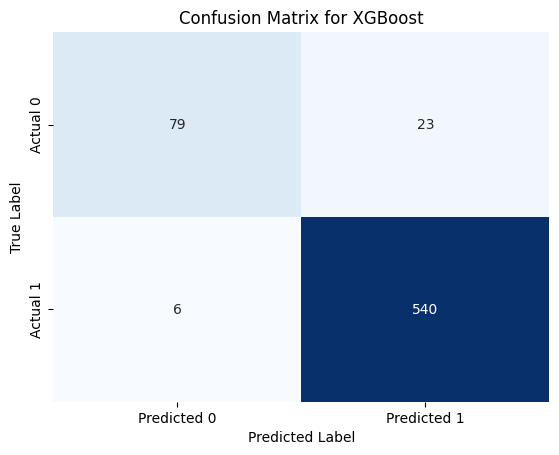

In [45]:
print("XGBoost Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix (XGBoost):")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost')
plt.show()